## Masked Autoencoders: Visualization Demo

This is a visualization demo using our pre-trained MAE models. No GPU is needed.

### Creazione dataset 9 canali

In [2]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from astropy.io import fits
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as npmenom
import matplotlib.pyplot as plt
import sunpy
from sunpy.map import Map
import sys
import os
import requests
import torch.nn as nn
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from torch import optim 
#from utils import validate_one_epoch, run_one_image, show_image

from torch.utils.data import DataLoader


torch.manual_seed(1)
from functools import partial
from mae.models_mae_2 import mae_model_channel_masking_9ch_with_temporal_attn
from mae import models_mae_2
from  torchvision.transforms import transforms


from mae.MAE import new_mae_trial_small_patches

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

from dataset import SDO_Dataset_channels_FAST
import random

train_years = list(range(2011, 2021))
val_years   = list(range(2021, 2023))
test_years  = list(range(2023, 2026))
image_size = 1024

zarr_path = "/home/gpatane/Dataset/zarr_file_magnetogram_1024_ORDINATO.zarr"
json_stats = "/home/gpatane/Dataset/statistiche_globali.json"
wavelengths = ['1700A', '1600A', '335A', '304A', '211A', '193A', '171A', '131A', 'Magnetogram']
#['1700A', '1600A', '335A', '304A', '211A', '193A', '171A', '131A', '94A', 'Ic_noLimbDark', 'Magnetogram']


train_dataset = SDO_Dataset_channels_FAST(zarr_path, json_stats, train_years, wavelengths, target_size=image_size)
validation_dataset = SDO_Dataset_channels_FAST(zarr_path, json_stats, val_years, wavelengths, target_size=image_size)
test_dataset = SDO_Dataset_channels_FAST(zarr_path, json_stats, test_years, wavelengths, target_size=image_size)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=4, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=4)


## Carico modello a 9 canali


In [9]:
import wandb
import os
from tqdm import tqdm
from mae.models_mae_2 import MaskedAutoencoderViT, mae_model_channel_masking_9ch_with_temporal_attn


def load_checkpoint_with_compile_fix(model, checkpoint_path, device):
    """Carica checkpoint gestendo il prefisso _orig_mod. da torch.compile()"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint["model_state_dict"]
    
    # Rimuovi prefisso _orig_mod. se presente (da torch.compile())
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("_orig_mod."):
            new_state_dict[k[10:]] = v  # Rimuovi "_orig_mod."
        else:
            new_state_dict[k] = v
    
    model.load_state_dict(new_state_dict, strict=False)
    return model

    
model = mae_model_channel_masking_9ch_with_temporal_attn(
    img_size=1024,
    patch_size=16,
    in_chans=9,
).to(device)
checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/checkpoint_epoch55.pth'
#checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/best_model.pth'
if os.path.exists(checkpoint_path):
    model = load_checkpoint_with_compile_fix(model, checkpoint_path, device)


In [3]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# --- NUOVE IMPORTAZIONI ---
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

def visualize_channel_masking_reconstruction(model, data_loader, device, wavelengths, mask_channels=None, denormalize=False):
    """
    Visualizza la ricostruzione con mascheramento dei canali calcolando SSIM, MSE e PSNR.
    
    Args:
        denormalize: Se True, denormalizza le predizioni se il modello è stato allenato con norm_pix_loss=True
    """
    model.eval()
    
    # Variabili per accumulare le metriche medie del batch (opzionale)
    metrics_log = {'mse': [], 'psnr': [], 'ssim': []}
    
    with torch.no_grad():
        # Prendi un batch
        img, date = next(iter(data_loader))
        
        batch_original = img.clone()
        batch = img.to(device)
        
        # Se norm_pix_loss=True, calcola media e varianza per la denormalizzazione
        if denormalize and model.norm_pix_loss:
            target = model.patchify(batch) 
            patch_mean = target.mean(dim=-1, keepdim=True) 
            patch_var = target.var(dim=-1, keepdim=True)  
            patch_std = (patch_var + 1.e-6) ** 0.5
        
        # Determina quanti e quali canali mascherare
        n_img_mask = mask_channels if mask_channels is not None else model.n_img_mask if model.n_img_mask is not None else random.randint(1, model.in_chans - 1)
        channel_indices = random.sample(range(model.in_chans), n_img_mask)
        print(f"Data frame: {date[0]}")
        print(f"Canali mascherati: {[wavelengths[i] for i in channel_indices]}")
        
        # Forward pass
        loss, pred, mask = model(batch)
        
        # Denormalizza se necessario
        if denormalize and model.norm_pix_loss:
            pred_denorm = pred * patch_std + patch_mean
            reconstructed = model.unpatchify(pred_denorm)
        else:
            reconstructed = model.unpatchify(pred)
        
        # Visualizza
        B, C, H, W = batch.shape
        fig, axes = plt.subplots(3, C, figsize=(C*3, 10))
        
        for c in range(C):
            # 1. Assegnazione Colormap
            if wavelengths[c] in ['Magnetogram', 'Ic_noLimbDark']:
                cmap = 'gray'
            else:
                cmap = 'sdoaia' + wavelengths[c].replace('A', '')
                
            img_original = batch[0, c].cpu().numpy()
            img_recon = reconstructed[0, c].cpu().numpy()
            
            # 2. Calcolo dei percentili
            vmin, vmax = np.percentile(img_original, [1.0, 99.5])
            if vmax - vmin < 1e-5:
                vmax = vmin + 0.1

            # --- RIGA 1: ORIGINALE ---
            ax = axes[0, c]
            ax.imshow(img_original, cmap=cmap, vmin=vmin, vmax=vmax)
            title_color = 'red' if c in channel_indices else 'black'
            ax.set_title(f'{wavelengths[c]}\n{"MASKED" if c in channel_indices else "visible"}', 
                        fontsize=11, color=title_color, fontweight='bold' if c in channel_indices else 'normal')
            ax.axis('off')
            
            if c in channel_indices:
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(3)
                    spine.set_visible(True)
            
            # --- RIGA 2: INPUT ---
            ax = axes[1, c]
            if c in channel_indices:
                ax.imshow(np.zeros_like(img_original), cmap='gray', vmin=0, vmax=1)
                ax.set_title('Input: ZERO', fontsize=10, color='red')
            else:
                ax.imshow(img_original, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.set_title('Input: original', fontsize=10)
            ax.axis('off')
            
            # --- RIGA 3: RICOSTRUITO (CON METRICHE) ---
            ax = axes[2, c]
            
            if c in channel_indices:
                ax.imshow(img_recon, cmap=cmap, vmin=vmin, vmax=vmax)
                
                # --- CALCOLO METRICHE ---
                # Definiamo il data_range effettivo del segnale per questo canale
                d_range = img_original.max() - img_original.min()
                if d_range < 1e-5: 
                    d_range = 1.0 # Sicurezza contro divisioni per zero
                
                mse_val = mean_squared_error(img_original, img_recon)
                psnr_val = peak_signal_noise_ratio(img_original, img_recon, data_range=d_range)
                ssim_val = structural_similarity(img_original, img_recon, data_range=d_range)
                
                # Salvataggio nel log
                metrics_log['mse'].append(mse_val)
                metrics_log['psnr'].append(psnr_val)
                metrics_log['ssim'].append(ssim_val)
                
                # Mostra le metriche nel titolo
                title_str = f'RECONSTRUCTED!\nMSE: {mse_val:.4f}\nPSNR: {psnr_val:.1f}dB\nSSIM: {ssim_val:.3f}'
                ax.set_title(title_str, fontsize=9, color='green', fontweight='bold')
            else:
                ax.imshow(img_original, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.set_title('Original', fontsize=10)
            ax.axis('off')
        
        # Etichette di riga
        axes[0, 0].text(-0.1, 0.5, 'Original', transform=axes[0, 0].transAxes, 
                       rotation=90, va='center', ha='right', fontsize=14, fontweight='bold')
        axes[1, 0].text(-0.1, 0.5, 'Model Input', transform=axes[1, 0].transAxes, 
                       rotation=90, va='center', ha='right', fontsize=14, fontweight='bold')
        axes[2, 0].text(-0.1, 0.5, 'Reconstructed', transform=axes[2, 0].transAxes, 
                       rotation=90, va='center', ha='right', fontsize=14, fontweight='bold')
        
        # Stampa a terminale le medie
        if metrics_log['mse']:
            print(f"--- Metriche Medie Canali Mascherati ---")
            print(f"MSE: {np.mean(metrics_log['mse']):.4f} | PSNR: {np.mean(metrics_log['psnr']):.2f} dB | SSIM: {np.mean(metrics_log['ssim']):.4f}")

        plt.tight_layout()
        fig.suptitle(f'Channel Masking Reconstruction | Date: {date[0]}\nLoss: {loss.item():.4f}', 
                    fontsize=16, y=1.05)
        plt.show()
        
        return loss, reconstructed, channel_indices

## Testing

In [3]:
from utils import validate_one_epoch
avg_epoch_loss, avg_epoch_ssim = validate_one_epoch(model, test_loader, device)
print(f' average loss: {avg_epoch_loss:.4f}, average ssim: {avg_epoch_ssim:.4f} ')

 average loss: 0.0770, average ssim: 0.8370 



masking 4 images: average loss: 0.0750, average ssim: 0.8472

🎨 Visualizzazione ricostruzione con mascheramento canali:
Data frame: 2023-04-28T12:00:28.745
Canali mascherati: ['1600A']
--- Metriche Medie Canali Mascherati ---
MSE: 0.0034 | PSNR: 24.69 dB | SSIM: 0.4880


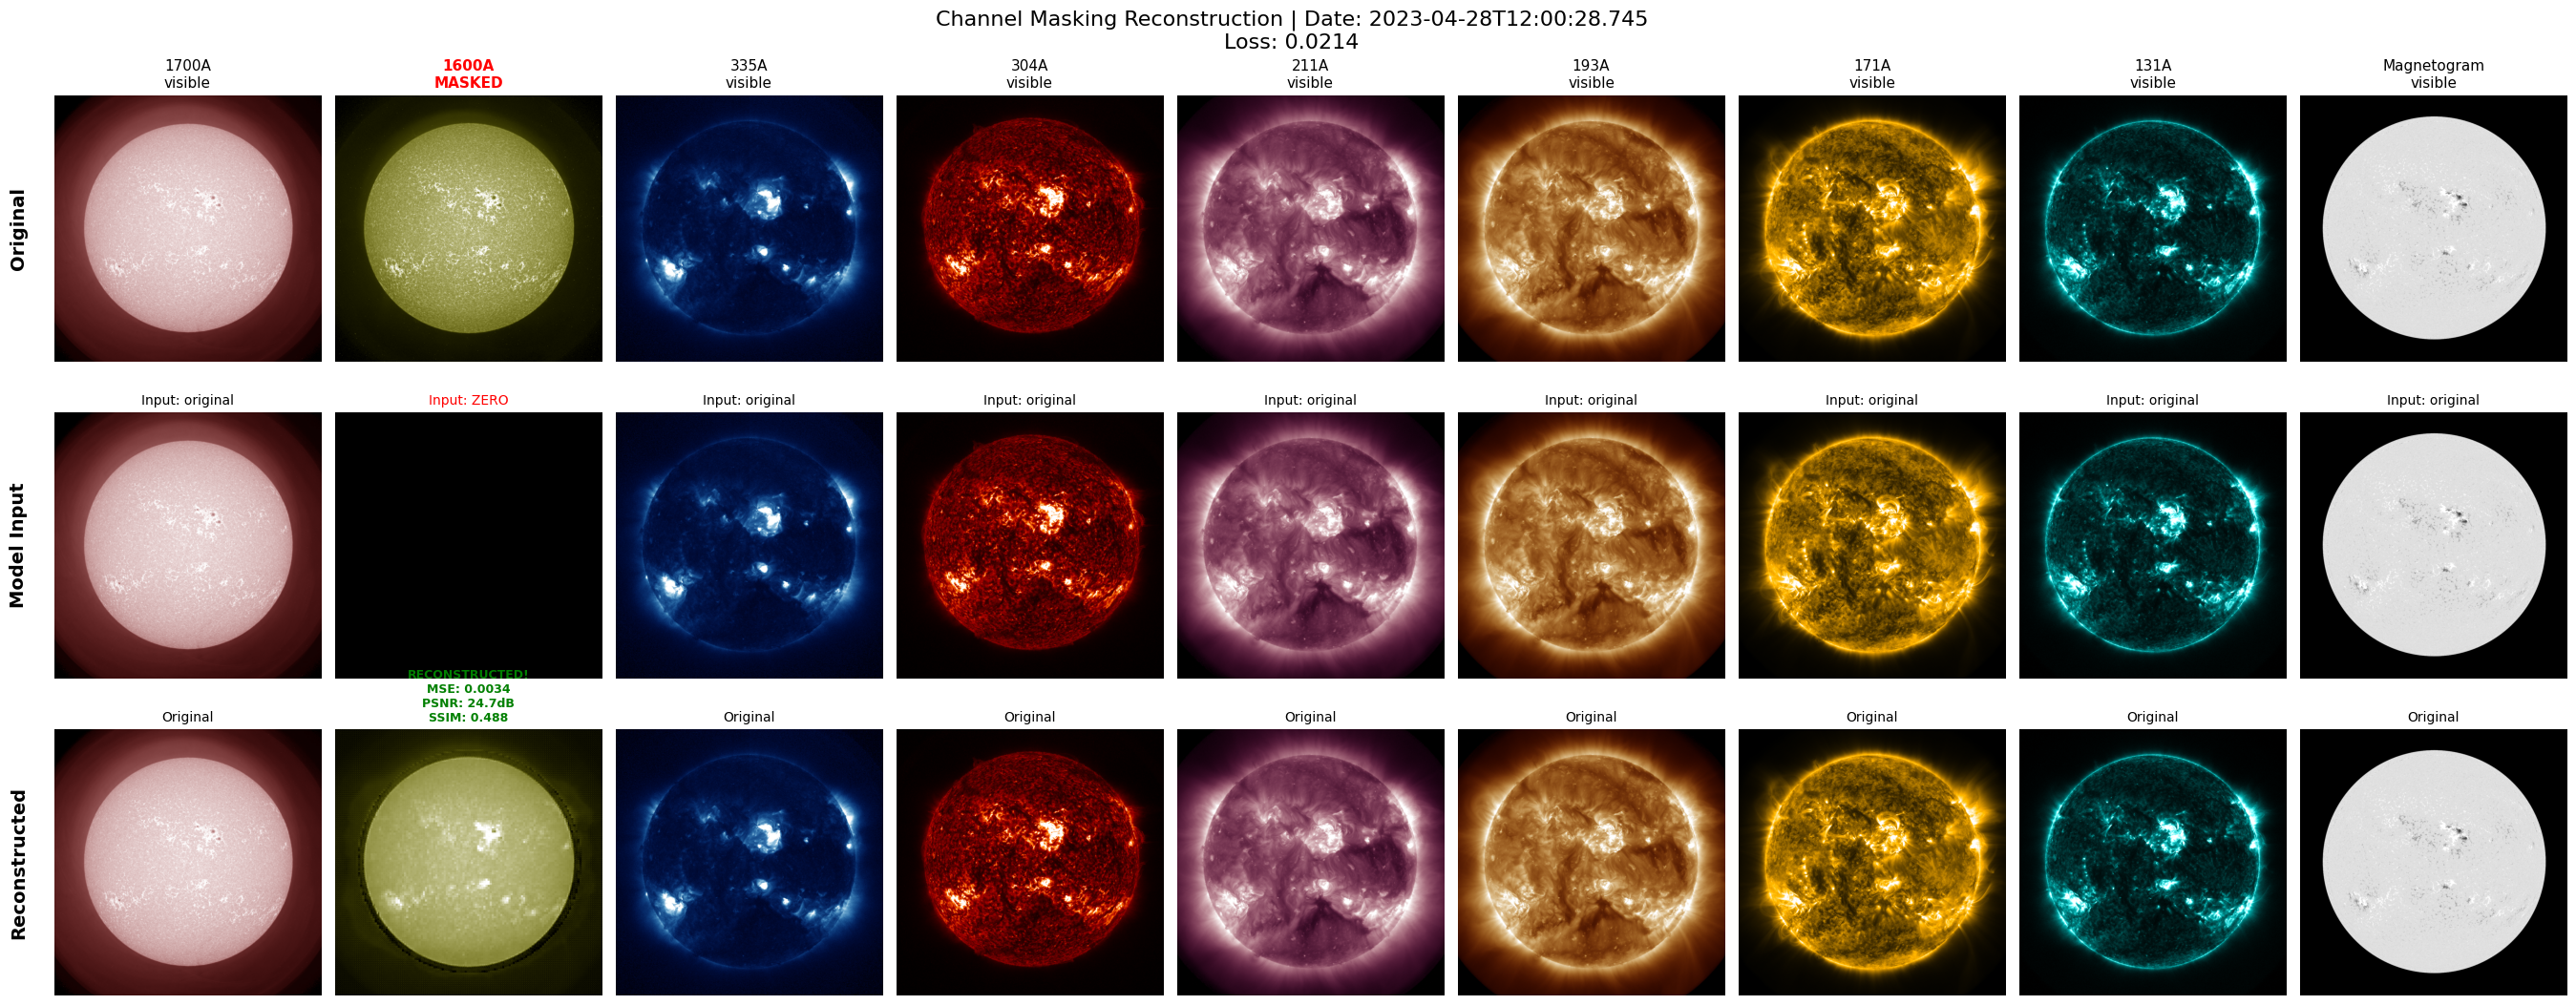

: 

In [ ]:
def load_checkpoint_with_compile_fix(model, checkpoint_path, device):
    """Carica checkpoint gestendo il prefisso _orig_mod. da torch.compile()"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint["model_state_dict"]
    
    # Rimuovi prefisso _orig_mod. se presente (da torch.compile())
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("_orig_mod."):
            new_state_dict[k[10:]] = v  # Rimuovi "_orig_mod."
        else:
            new_state_dict[k] = v
    
    model.load_state_dict(new_state_dict, strict=False)
    return model

model = mae_model_channel_masking_9ch_with_temporal_attn(
    img_size=1024,
    patch_size=8,
    in_chans=len(wavelengths),
    mask_ratio=0,
    norm_pix_loss = True
    
).to(device)

#checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/ch9_1024_p16/best_model.pth'
#checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/ch9_1024_p16_normpix/best_model.pth'
checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/ch9_1024_p8_normpix/best_model.pth' 
if os.path.exists(checkpoint_path):
    model = load_checkpoint_with_compile_fix(model, checkpoint_path, device)

from utils import validate_one_epoch
print("🎨 Visualizzazione ricostruzione con mascheramento canali:")
# denormalize=True perché il modello è stato allenato con norm_pix_loss=True
loss, recon, masked_channels = visualize_channel_masking_reconstruction(
    model, test_loader, device, wavelengths, mask_channels=1, denormalize=True
)


In [4]:
import torch
import random
import numpy as np
from tqdm import tqdm
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

def evaluate_channel_masking_inference(model, data_loader, device, mask_channels=None, denormalize=False):
    """
    Esegue l'inferenza su tutto il DataLoader per valutare le prestazioni 
    di ricostruzione con mascheramento dei canali.
    
    Ritorna un dizionario con le metriche medie (Loss, MSE, PSNR, SSIM).
    """
    model.eval()
    
    # Accumulatori per le metriche su tutto il dataset
    metrics_log = {'loss': [], 'mse': [], 'psnr': [], 'ssim': []}
    
    with torch.no_grad():
        # tqdm crea una comoda barra di progresso nel terminale
        for img, _ in tqdm(data_loader, desc="Evaluando DataLoader"):
            
            batch = img.to(device)
            B, C, H, W = batch.shape
            
            # Se norm_pix_loss=True, calcola media e varianza per la denormalizzazione
            if denormalize and getattr(model, 'norm_pix_loss', False):
                target = model.patchify(batch) 
                patch_mean = target.mean(dim=-1, keepdim=True) 
                patch_var = target.var(dim=-1, keepdim=True)  
                patch_std = (patch_var + 1.e-6) ** 0.5
            
            # Determina quanti e quali canali mascherare (per l'intero batch corrente)
            n_img_mask = mask_channels if mask_channels is not None else getattr(model, 'n_img_mask', random.randint(1, model.in_chans - 1))
            channel_indices = random.sample(range(model.in_chans), n_img_mask)
            
            # Forward pass
            loss, pred, mask = model(batch)
            metrics_log['loss'].append(loss.item())
            
            # Denormalizza se necessario e ricostruisci
            if denormalize and getattr(model, 'norm_pix_loss', False):
                pred_denorm = pred * patch_std + patch_mean
                reconstructed = model.unpatchify(pred_denorm)
            else:
                reconstructed = model.unpatchify(pred)
            
            # Spostiamo i tensori su CPU una sola volta per tutto il batch
            batch_cpu = batch.cpu().numpy()
            recon_cpu = reconstructed.cpu().numpy()
            
            # Calcolo metriche per ogni immagine nel batch (b) e per ogni canale mascherato (c)
            for b in range(B):
                for c in channel_indices:
                    img_original = batch_cpu[b, c]
                    img_recon = recon_cpu[b, c]
                    
                    # Definiamo il data_range effettivo
                    d_range = img_original.max() - img_original.min()
                    if d_range < 1e-5: 
                        d_range = 1.0 # Sicurezza contro divisioni per zero
                    
                    # Scikit-image metrics
                    mse_val = mean_squared_error(img_original, img_recon)
                    psnr_val = peak_signal_noise_ratio(img_original, img_recon, data_range=d_range)
                    ssim_val = structural_similarity(img_original, img_recon, data_range=d_range)
                    
                    # Salvataggio
                    metrics_log['mse'].append(mse_val)
                    metrics_log['psnr'].append(psnr_val)
                    metrics_log['ssim'].append(ssim_val)

    # --- Aggregazione Finale ---
    avg_metrics = {
        'loss': np.mean(metrics_log['loss']),
        'mse': np.mean(metrics_log['mse']),
        'psnr': np.mean(metrics_log['psnr']),
        'ssim': np.mean(metrics_log['ssim'])
    }
    
    print("\n" + "="*40)
    print(" RISULTATI FINALI INFERENZA")
    print("="*40)
    print(f"Loss Media: {avg_metrics['loss']:.4f}")
    print(f"MSE Medio:  {avg_metrics['mse']:.4f}")
    print(f"PSNR Medio: {avg_metrics['psnr']:.2f} dB")
    print(f"SSIM Medio: {avg_metrics['ssim']:.4f}")
    print("="*40 + "\n")
    
    return avg_metrics

In [5]:
#inferenza su tutto il test_loader maskerando 1 canale per volta e calcolando le metriche medie di MSE, PSNR e SSIM per ogni canale mascherato
model = mae_model_channel_masking_9ch_with_temporal_attn(
    img_size=1024,
    patch_size=8,
    in_chans=len(wavelengths),
    mask_ratio=0,
    norm_pix_loss = True
    
).to(device)
checkpoint_path = '/home/gpatane/SDO_downstream/mae_project/checkpoints/ch9_1024_p8_normpix/best_model.pth' 

mask_channels = [1,4,8]

if os.path.exists(checkpoint_path):
    model = load_checkpoint_with_compile_fix(model, checkpoint_path, device)
dict = {}
for mask in mask_channels:

    avg_metrics = evaluate_channel_masking_inference(model, test_loader, device, mask_channels=mask, denormalize=False)
    dict[mask] = avg_metrics
    

Evaluando DataLoader: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1934/1934 [3:14:04<00:00,  6.02s/it]



 RISULTATI FINALI INFERENZA
Loss Media: 0.0943
MSE Medio:  0.4648
PSNR Medio: 6.89 dB
SSIM Medio: 0.1390



Evaluando DataLoader:   0%|▋                                                                                                                                                                                                | 7/1934 [01:05<5:00:16,  9.35s/it]


KeyboardInterrupt: 

Evaluando DataLoader: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1934/1934 [3:14:04<00:00,  6.02s/it]

========================================
 RISULTATI FINALI INFERENZA
========================================
Loss Media: 0.0943
MSE Medio:  0.4648
PSNR Medio: 6.89 dB
SSIM Medio: 0.1390
========================================